# Setup

In [2]:
import os

BASE_DIR = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
PATH_TO_DATASET = os.path.join(BASE_DIR, 'dataset', 'artificial data')

lst_files = sorted(os.listdir(PATH_TO_DATASET))

for f_name in lst_files:
    print(f_name)

dna_10.txt
dna_1280.txt
dna_160.txt
dna_20.txt
dna_320.txt
dna_40.txt
dna_640.txt
dna_80.txt


In [3]:
PATH_FILES = [os.path.join(PATH_TO_DATASET, i) for i in lst_files]

for f_path in PATH_FILES:
    print(f_path)

d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_10.txt
d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_1280.txt
d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_160.txt
d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_20.txt
d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_320.txt
d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_40.txt
d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_640.txt
d:\DAA_PJ_F\dna-matching\dataset\artificial data\dna_80.txt


In [4]:
import ast

input_strings = []
patterns = []
num_of_misses = []
result = []


for f_path in PATH_FILES:
    with open(f_path, 'r') as f:
        lines = f.readlines()

        for line in lines:
            line = line.strip()
            if not line:
                continue
            elements = line.split(' ', maxsplit=3)
            
            input_strings.append(elements[0])
            patterns.append(elements[1])
            num_of_misses.append(int(elements[2]))
            result.append(ast.literal_eval(elements[3]))

print(f"Total samples loaded: {len(input_strings)}")

Total samples loaded: 80


In [5]:
import random

seed = 42
n_samples = 10

random.seed(seed)

indices = random.sample(range(len(input_strings)), min(n_samples, len(input_strings)))

print('Example:')

for idx, i in enumerate(indices, start=1):
    print(f"Sample {idx}:")
    print("Input string:", input_strings[i])
    print("Pattern:", patterns[i])
    print("Num of misses:", num_of_misses[i])
    print("Result:", result[i])
    print("-" * 50)

Example:
Sample 1:
Input string: GCCACGCCAGCACGATAAAGGTTGGGCGACGAGTGCGTACTTCACGGTCGAGATCGAACAGTTATATCACACTCAAAACGGGTAGTACTACCTGCTCGTTTGGGTTGATGCTTTCAAATAAGTGGAAAATACGACCCTCGATAGGTGTAACGGGATGCTCCGGTAGGACTGAGGATACCTACCTCACAAATAGTTGTACGTACACGTCCATTGGGCACACGAGCTTCTGAAGAGACACCCATATGTATGGCTCGGGCAGTGCGACGGGACGATTCTCCAGTCCCAGGGCGCGGTTCCGACCCTGCGCATTTGGAGTGATAATTAATCAGTTGGATGATACATTTCGTCGCGGTATTGAGGTGAACTCTTAGAAAAAGACCAAACAGGAAGATCGCAGTTCAATTGTTATTCGATGATGCCCTAGGGGCCACAGCTTACAGCACAAAGGGTTTAGAGGGGCTCTGCGCTGTGCCTTATTCCCTCGATAGTACACCATCATCTCAACTTTATGGGGCCAGGGGTTATCTGGCTATCCAGTGATCACAAATTATTATAATTCGGCTCGAATATTTGGATTGCGTCTCTACGCAGTCGCCACATCGCAAGGTCACACACTATCGGCCCCCCCACCTGGCCCGGCCCCGCTAACAGGTAGAACGACACGTAGCTTGGTAGACCGTTGACTAGAAACGCCTACGTCGGTCCGACTCAGAGCAAACAGTCGGTAGTATGGGGGCTTCGCCCCGAATTGTTGCACCATCTGCACATGTATACGCTATCGAGGCTCTGGTGAACGTCAAGCAGGAAATGATACAGTCTACTTTAGCCATAATCGCCTTGGCTTCTCCGCCCTACCAGAATCGCTGAAAACGACGGTGCTTATTTTTCAGCCAGTCTTCGATGCCGCATAGAGCATCCCGTGTCTGCTCCCAAGAGACCAATTGAGTCTTAAACATAATGAATCCCC

# Experiment

In [6]:
def valid(pred, expected):
    return sorted(pred) == sorted(expected)

def print_random_samples(input_strings, patterns, num_of_misses, result, seed=42, n_samples=10):
    random.seed(seed)

    indices = random.sample(
        range(len(input_strings)),
        min(n_samples, len(input_strings))
    )

    print(f"{len(indices)} sample with seed = {seed}")
    print()

    for idx, i in enumerate(indices, start=1):
        print(f"Sample {idx}")
        print("Text       :", input_strings[i])
        print("Pattern    :", patterns[i])
        print("k          :", num_of_misses[i])
        print("Expected   :", result[i])
        print()


print_random_samples(
    input_strings,
    patterns,
    num_of_misses,
    result,
    seed=42,
    n_samples=10
)

10 sample with seed = 42

Sample 1
Text       : GCCACGCCAGCACGATAAAGGTTGGGCGACGAGTGCGTACTTCACGGTCGAGATCGAACAGTTATATCACACTCAAAACGGGTAGTACTACCTGCTCGTTTGGGTTGATGCTTTCAAATAAGTGGAAAATACGACCCTCGATAGGTGTAACGGGATGCTCCGGTAGGACTGAGGATACCTACCTCACAAATAGTTGTACGTACACGTCCATTGGGCACACGAGCTTCTGAAGAGACACCCATATGTATGGCTCGGGCAGTGCGACGGGACGATTCTCCAGTCCCAGGGCGCGGTTCCGACCCTGCGCATTTGGAGTGATAATTAATCAGTTGGATGATACATTTCGTCGCGGTATTGAGGTGAACTCTTAGAAAAAGACCAAACAGGAAGATCGCAGTTCAATTGTTATTCGATGATGCCCTAGGGGCCACAGCTTACAGCACAAAGGGTTTAGAGGGGCTCTGCGCTGTGCCTTATTCCCTCGATAGTACACCATCATCTCAACTTTATGGGGCCAGGGGTTATCTGGCTATCCAGTGATCACAAATTATTATAATTCGGCTCGAATATTTGGATTGCGTCTCTACGCAGTCGCCACATCGCAAGGTCACACACTATCGGCCCCCCCACCTGGCCCGGCCCCGCTAACAGGTAGAACGACACGTAGCTTGGTAGACCGTTGACTAGAAACGCCTACGTCGGTCCGACTCAGAGCAAACAGTCGGTAGTATGGGGGCTTCGCCCCGAATTGTTGCACCATCTGCACATGTATACGCTATCGAGGCTCTGGTGAACGTCAAGCAGGAAATGATACAGTCTACTTTAGCCATAATCGCCTTGGCTTCTCCGCCCTACCAGAATCGCTGAAAACGACGGTGCTTATTTTTCAGCCAGTCTTCGATGCCGCATAGAGCATCCCGTGTCTGCTCCCAAGAGACCAATTGAGTCTTAA

In [7]:
import pandas as pd

def test_algorithm_on_file(algo, f_path):
    records = []

    for i in range(len(input_strings)):
        text = input_strings[i]
        pattern = patterns[i]
        k = num_of_misses[i]
        expected = result[i]

        eval_result = algo.evaluate(text, pattern, k)
        pred = eval_result["matches"]

        records.append({
            "file": os.path.basename(f_path),
            "input_size": len(text),
            "sample_id": i,
            "algorithm": algo.name,
            "text_len": len(text),
            "pattern_len": len(pattern),
            "k": k,
            "runtime_sec": eval_result["runtime_sec"],
            "num_expected": len(expected),
            "num_pred": eval_result["num_matches"],
            "valid": valid(pred, expected),
            "expected": expected,
            "pred": pred,
        })

    return pd.DataFrame(records)

## KMP-based Filtering + Verification

In [8]:
from kmp import KMPWithVerification

kmp_algo = KMPWithVerification()

kmp_dfs = []

for f_path in PATH_FILES:
    df_file = test_algorithm_on_file(kmp_algo, f_path)
    kmp_dfs.append(df_file)

df_kmp = pd.concat(kmp_dfs, ignore_index=True)

df_kmp.head()

,file,input_size,sample_id,algorithm,text_len,pattern_len,k,runtime_sec,num_expected,num_pred,valid,expected,pred
0,dna_10.txt,10,0,KMP-based Filtering + Verification,10,3,0,0.000021,1,1,True,[1],[1]
1,dna_10.txt,10,1,KMP-based Filtering + Verification,10,3,0,0.000009,1,1,True,[3],[3]
2,dna_10.txt,10,2,KMP-based Filtering + Verification,10,3,0,0.000006,1,1,True,[6],[6]
3,dna_10.txt,10,3,KMP-based Filtering + Verification,10,3,1,0.000026,2,2,True,"[2, 3]","[2, 3]"
4,dna_10.txt,10,4,KMP-based Filtering + Verification,10,3,0,0.000005,1,1,True,[1],[1]


In [9]:
kmp_summary = df_kmp.groupby("input_size").agg(
    num_samples=("sample_id", "count"),
    num_correct=("valid", "sum"),
    avg_runtime_sec=("runtime_sec", "mean"),
    median_runtime_sec=("runtime_sec", "median"),
    min_runtime_sec=("runtime_sec", "min"),
    max_runtime_sec=("runtime_sec", "max"),
    total_runtime_sec=("runtime_sec", "sum"),
    avg_pattern_len=("pattern_len", "mean"),
    avg_k=("k", "mean"),
).reset_index()

kmp_summary["num_wrong"] = kmp_summary["num_samples"] - kmp_summary["num_correct"]
kmp_summary["accuracy"] = kmp_summary["num_correct"] / kmp_summary["num_samples"]

print(f"KMP - Total accuracy: {df_kmp['valid'].mean():.4f}")
kmp_summary

KMP - Total accuracy: 1.0000


,input_size,num_samples,num_correct,avg_runtime_sec,median_runtime_sec,min_runtime_sec,max_runtime_sec,total_runtime_sec,avg_pattern_len,avg_k,num_wrong,accuracy
0,10,80,80,0.000007,0.000004,0.000002,0.000044,0.000546,3.0,0.3,0,1.0
1,20,80,80,0.000006,0.000004,0.000003,0.000014,0.000467,3.0,0.3,0,1.0
2,40,80,80,0.000008,0.000006,0.000005,0.000018,0.000614,4.0,0.2,0,1.0
3,80,80,80,0.000020,0.000017,0.000009,0.000053,0.001588,8.0,0.7,0,1.0
4,160,80,80,0.000096,0.000097,0.000037,0.000191,0.007669,16.0,3.5,0,1.0
5,320,80,80,0.000326,0.000324,0.000100,0.000683,0.026062,32.0,6.5,0,1.0
6,640,80,80,0.001113,0.000950,0.000135,0.003662,0.089035,64.0,11.9,0,1.0
7,1280,80,80,0.005161,0.004550,0.001313,0.014948,0.412911,128.0,25.7,0,1.0


In [ ]:
wrong_kmp = df_kmp[df_kmp["valid"] == False]
print(f"KMP - Wrong predictions: {len(wrong_kmp)}")
if len(wrong_kmp) > 0:
    print(wrong_kmp[["file", "sample_id", "k", "expected", "pred"]].head(10))

KMP - Wrong predictions: 0


## Biểu diễn thời gian chạy

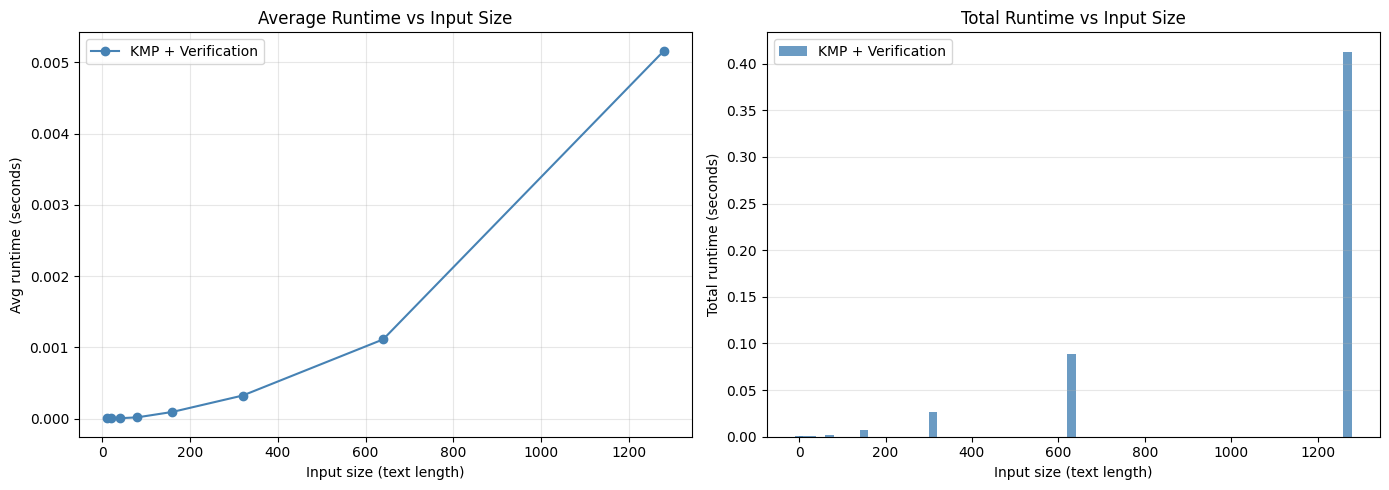

Saved: runtime_comparison.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(
    kmp_summary["input_size"],
    kmp_summary["avg_runtime_sec"],
    marker='o', label='KMP + Verification', color='steelblue'
)
ax1.set_xlabel('Input size (text length)')
ax1.set_ylabel('Avg runtime (seconds)')
ax1.set_title('Average Runtime vs Input Size')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(
    kmp_summary["input_size"] - 10,
    kmp_summary["total_runtime_sec"],
    width=20, label='KMP + Verification', color='steelblue', alpha=0.8
)

ax2.set_xlabel('Input size (text length)')
ax2.set_ylabel('Total runtime (seconds)')
ax2.set_title('Total Runtime vs Input Size')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('runtime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: runtime_comparison.png")